# Multilayer neural networks

Neural networks model mathematical functions mapping inputs to outputs based on the structure and parameters of the network. A multilayer neural network can be understood as a network of perceptrons, since it has multiple layers of interconnected neurons. Multilayer neural networks are well\-suited for solving non\-linear problems due to its ability to capture complex patterns and relationships in the data. Multilayer neural networks are also known as a deep neural networks.

Multilayer neural networks have an input layer, hidden layers, and an output layer:

- Input layer: This layer gets the input features of the problem.
- Hidden layers: These layers are between the input and output layers. They perform computations and learn representations of the input data.
- Output layer: This layer produces the output of the network, which is typically the predicted value or class label.

The activation functions introduce non\-linearity into the network, allowing it to model complex relationships. Common activation functions used in deep neural networks include:

- Rectified Linear Unit \(ReLU\) is widely used due to its simplicity and ability to handle non\-linearities. If the input value 𝑥 is negative, then the output value will be $0$, otherwise, the output value will be 𝑥. The ReLU activation function is commonly used for hidden layers.<br/><br/>
  𝑔\(𝑥\) = max⁡\(0, 𝑥\)
  <br/>
- Logistic Sigmoid squeezes an input real value between $0$ and $1$. The larger the input, the closer the output value will be to $1.0$, while the smaller the input, the closer the output will be to $0$. Sigmoid is useful for binary classification problems.
  <br/><br/>
  𝑔\(𝑥\) = $1/(1+ 𝑒^{−𝑥})$ 
  <br/>
- Hyperbolic Tangent \(Tanh\) maps the input values to the range $[-1, 1]$. Tanh is suitable for problems with negative inputs. The larger the input, the closer the output value will be to $1$, while the smaller the input, the closer the output will be to $-1$.
  <br/><br/>
  𝑔\(𝑥\) = $(e^x - e^{-x})/(e^x + e^{-x})$ 
  <br/>
- Other activation functions like Leaky ReLU, ELU, and softmax can be used depending on the specific problem requirements.

By stacking multiple hidden layers with non\-linear activation functions, a multilayer neural network can learn intricate representations of the input data. Each layer captures higher\-level features and combinations of lower\-level features, allowing the network to learn complex non\-linear patterns.

During the training process the network adjusts its weights and biases using optimization algorithms such as gradient descent and backpropagation. This iterative process fine\-tunes the network's parameters to minimize the difference between the predicted outputs and the actual targets to effectively solving non\-linear problems.

<img src="https://cocalc.com/blobs/Multilayer%20neural%20network%20with%20n%20inputs.png?uuid=4c794b3a-4984-43e8-ac6a-869a050f4c9b"   width="819px"  height="370px"  style="object-fit:cover"/>



In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

# set the variable TF_ENABLE_ONEDNN_OPTS=0

scaler = StandardScaler()

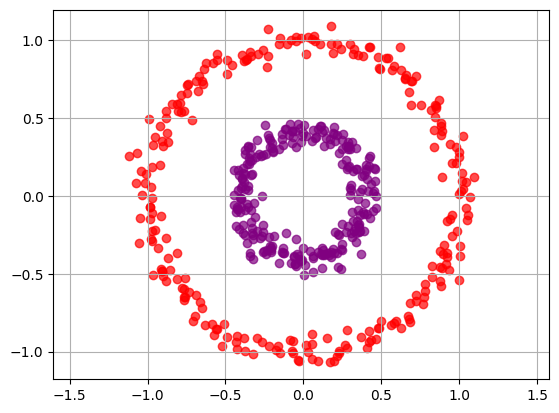

In [13]:
# generate a syntethic non-linearly separable dataset

X, y = make_circles(n_samples=500, noise=0.05, factor=0.4, random_state=0)

# split the dataset

X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=0)

# plot

plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1], color='red', alpha=0.7)
plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], color='purple', alpha=0.7)
plt.axis('equal')
plt.grid(True)
plt.show()

In [14]:
# plot the decision boundary

def plot_decision_boundary(model, X, y):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))

    grid = np.c_[xx.ravel(), yy.ravel()]

    predictions = model.predict(scaler.transform(grid))

    Z = predictions.reshape(xx.shape)

    plt.contourf(xx, yy, Z, levels=[0, 0.5, 1], alpha=0.2, colors=["white", "purple"])
    plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1], color='red', alpha=0.7)
    plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], color='purple', alpha=0.7)
    plt.axis('equal')
    plt.grid(True)
    plt.show()

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 1.0000 - loss: 0.0276  
Test Accuracy: 1.00
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step


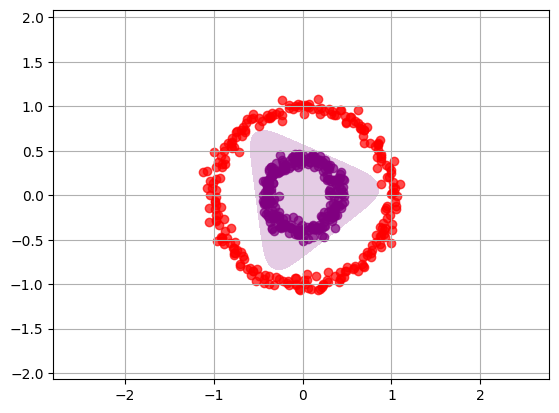

In [15]:
# two-input neural network with one hidden layer with 3 neurons and 1 output neuron

EPOCHS = 100
LAYER_1 = 3
LAYER_2 = 1

model = Sequential([Input(shape=(2,)), Dense(LAYER_1, activation='tanh'), Dense(LAYER_2, activation='sigmoid')])
model.compile(optimizer=Adam(learning_rate=0.01), loss='binary_crossentropy', metrics=['accuracy'])
model.fit(X_train, y_train, epochs=EPOCHS, batch_size=16, verbose=0)

# evaluate the model

loss, accuracy = model.evaluate(X_test, y_test, verbose=1)
print(f"Test Accuracy: {accuracy:.2f}")

plot_decision_boundary(model, X, y)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 1.0000 - loss: 0.0159 
Test Accuracy: 1.00
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step


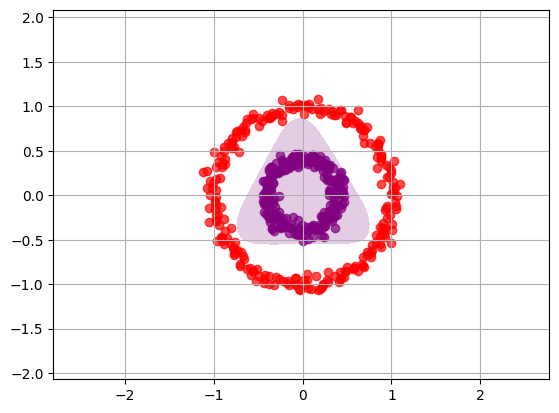

In [16]:
# two-input neural network with one hidden layer with up to 6 neurons and 1 output neuron

EPOCHS = 100
LAYER_1 = 6
LAYER_2 = 1

model = Sequential([Input(shape=(2,)), Dense(LAYER_1, activation='tanh'), Dense(LAYER_2, activation='sigmoid')])
model.compile(optimizer=Adam(learning_rate=0.01), loss='binary_crossentropy', metrics=['accuracy'])
model.fit(X_train, y_train, epochs=EPOCHS, batch_size=16, verbose=0)

# evaluate the model

loss, accuracy = model.evaluate(X_test, y_test, verbose=1)
print(f"Test Accuracy: {accuracy:.2f}")

plot_decision_boundary(model, X, y)

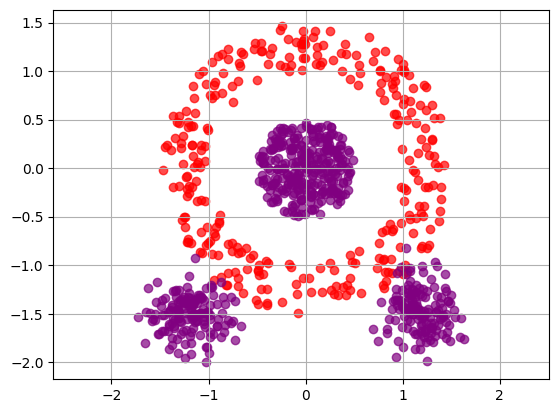

In [17]:
# generate a syntethic non-linearly separable dataset with three class A regions: central region (A), outer region (B), left and right lower regions (A)

# circular central region (class A)

n_points = 300
r = 0.5 * np.sqrt(np.random.rand(n_points))
theta = 2 * np.pi * np.random.rand(n_points)
x_central = r * np.cos(theta)
y_central = r * np.sin(theta)
labels_central = np.ones(n_points)

# outer region (class B)

r_outer = 1.0 + 0.5 * np.random.rand(n_points)
theta_outer = 2 * np.pi * np.random.rand(n_points)
x_outer = r_outer * np.cos(theta_outer)
y_outer = r_outer * np.sin(theta_outer)
labels_outer = np.zeros(n_points)

# left and right lower regions (class A)

x_left = np.random.normal(loc=-1.2, scale=0.2, size=n_points//2)
y_left = np.random.normal(loc=-1.5, scale=0.2, size=n_points//2)

x_right = np.random.normal(loc=1.2, scale=0.2, size=n_points//2)
y_right = np.random.normal(loc=-1.5, scale=0.2, size=n_points//2)

labels_lr = np.ones(n_points)

# combine the regions

X = np.concatenate([np.column_stack([x_central, y_central]),
                    np.column_stack([x_outer, y_outer]),
                    np.column_stack([x_left, y_left]),
                    np.column_stack([x_right, y_right])])

y = np.concatenate([labels_central, labels_outer, labels_lr])

# split the dataset

X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=0)

# plot

plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1], color='red', alpha=0.7)
plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], color='purple', alpha=0.7)
plt.axis('equal')
plt.grid(True)
plt.show()

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9928 - loss: 0.0156 
Test Accuracy: 0.99
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step


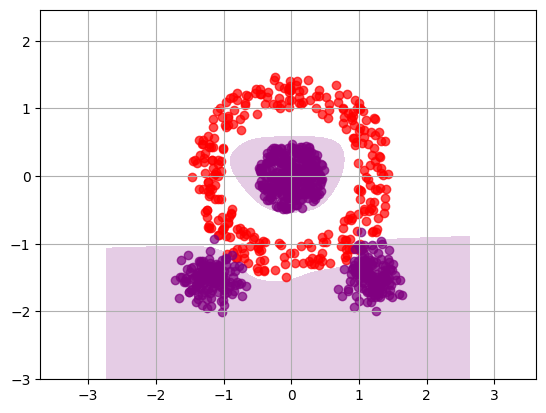

In [20]:
# two-input neural network with two hidden layers, the first layer has 10-12 neurons, the second layer has 3 neurons, and 1 output neuron


LAYER_1 = 5
LAYER_2 = 3
LAYER_3 = 1

model = Sequential([Input(shape=(2,)), Dense(LAYER_1, activation='tanh'), Dense(LAYER_2, activation='sigmoid'), Dense(LAYER_3, activation='sigmoid')])
model.compile(optimizer=Adam(learning_rate=0.01), loss='binary_crossentropy', metrics=['accuracy'])
model.fit(X_train, y_train, epochs=EPOCHS, batch_size=16, verbose=0)

# evaluate the model

loss, accuracy = model.evaluate(X_test, y_test, verbose=1)
print(f"Test Accuracy: {accuracy:.2f}")

plot_decision_boundary(model, X, y)